# 00 — Exploration

Notebook for data checks, data visualization, benchmark comparison and CPD sanity plots (time series of returns with change points).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "stoxx600"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")

Project root : /home/vincent/QR/ESILV/Pergam_MSc_2026
Processed dir: /home/vincent/QR/ESILV/Pergam_MSc_2026/data/processed/stoxx600


## 1. Load processed data

Both CSVs were produced by `01_data_loading.ipynb`:

- `stoxx600_processed.csv` — long format: `(date, ticker, price, *_ret, *_vol, exchange, country, region)`
- `benchmark_stoxx600_ew.csv` — stacked: `(date, benchmark ∈ {SXXR, EW}, price)`

In [2]:
stocks = pd.read_csv(PROCESSED_DIR / "stoxx600_processed.csv", parse_dates=["date"])
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv", parse_dates=["date"])

print(f"stocks     : {len(stocks):,} rows | {stocks['ticker'].nunique()} tickers "
      f"| {stocks['date'].min().date()} -> {stocks['date'].max().date()}")
print(f"benchmarks : {len(benchmarks):,} rows | {benchmarks['benchmark'].unique().tolist()}")
stocks.head()

stocks     : 1,947,399 rows | 597 tickers | 2013-01-01 -> 2026-04-10
benchmarks : 6,928 rows | ['EW', 'SXXR']


,date,ticker,price,1d_log_ret,20d_log_ret,252d_log_ret,1d_arith_ret,20d_arith_ret,252d_arith_ret,20d_vol,60d_vol,252d_vol,exchange,country,region
0,2013-01-01,A2A IM,0.2441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IM,Italy,Southern Europe
1,2013-01-01,AAK SS,38.4910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SS,Sweden,Nordic
2,2013-01-01,AAL LN,1096.4180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LN,United Kingdom,UK & Ireland
3,2013-01-01,AALB NA,11.6589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Netherlands,Western Europe
4,2013-01-01,ABBN SE,11.7295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE,Switzerland,Western Europe


## 2. Data quality checks

- coverage per ticker (number of observations)
- fraction of tickers alive per date
- distribution of 1d returns (sanity: heavy-tailed, near-zero mean)

Total unique dates : 3464
Ticker coverage    : min=366, median=3464, max=3464
Tickers with full history: 501 / 597


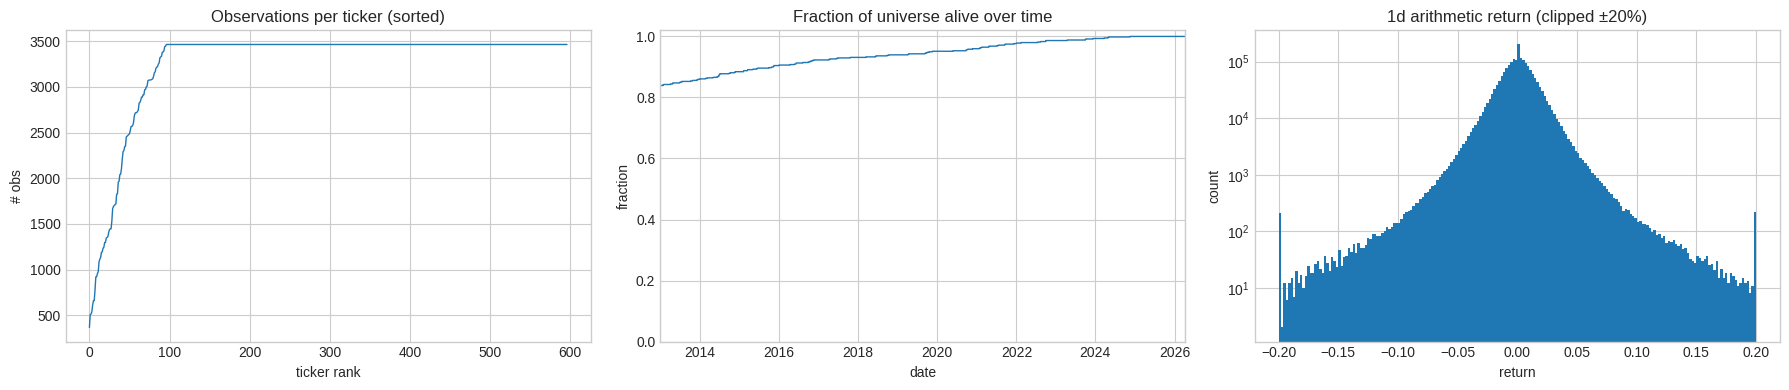

In [3]:
coverage = stocks.groupby("ticker")["date"].count().sort_values()
n_dates = stocks["date"].nunique()
alive = stocks.groupby("date")["ticker"].nunique() / stocks["ticker"].nunique()

print(f"Total unique dates : {n_dates}")
print(f"Ticker coverage    : min={coverage.min()}, median={int(coverage.median())}, max={coverage.max()}")
print(f"Tickers with full history: {(coverage == n_dates).sum()} / {len(coverage)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
coverage.reset_index(drop=True).plot(ax=axes[0], linewidth=1)
axes[0].set_title("Observations per ticker (sorted)")
axes[0].set_xlabel("ticker rank"); axes[0].set_ylabel("# obs")

alive.plot(ax=axes[1], linewidth=1)
axes[1].set_title("Fraction of universe alive over time")
axes[1].set_ylabel("fraction"); axes[1].set_ylim(0, 1.02)

stocks["1d_arith_ret"].dropna().clip(-0.2, 0.2).hist(ax=axes[2], bins=200)
axes[2].set_title("1d arithmetic return (clipped ±20%)")
axes[2].set_xlabel("return"); axes[2].set_ylabel("count")
axes[2].set_yscale("log")

plt.tight_layout(); plt.show()

## 3. Benchmark comparison — SXXR (cap-weighted) vs EW

Rebased to 100 at the first common date.

           CAGR (%)  Vol ann (%)  Sharpe  Max DD (%)
benchmark                                           
EW            15.78        15.18    1.04      -36.77
SXXR           9.94        15.47    0.64      -35.36


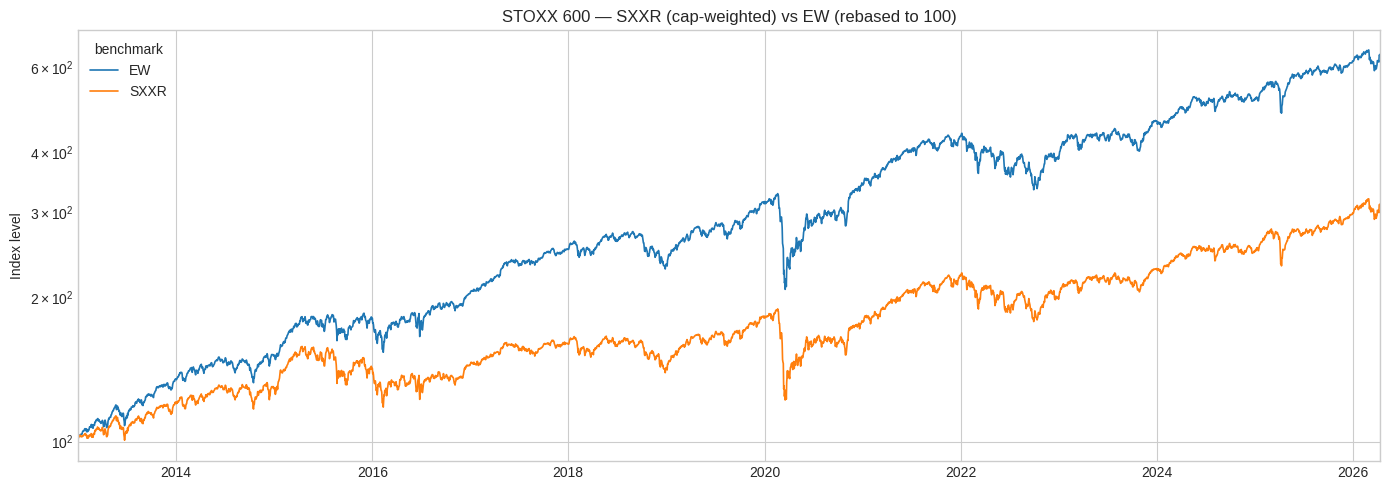

In [8]:
bench_wide = benchmarks.pivot(index="date", columns="benchmark", values="price").dropna()
bench_rebased = 100 * bench_wide / bench_wide.iloc[0]

rets = bench_wide.pct_change().dropna()
ann = lambda r: (1 + r.mean()) ** 252 - 1
vol = lambda r: r.std() * np.sqrt(252)
stats = pd.DataFrame({
    "CAGR (%)":     (ann(rets) * 100).round(2),
    "Vol ann (%)":  (vol(rets) * 100).round(2),
    "Sharpe":       (ann(rets) / vol(rets)).round(2),
    "Max DD (%)":   ((bench_rebased / bench_rebased.cummax() - 1).min() * 100).round(2),
})
print(stats)

fig, ax = plt.subplots()
bench_rebased.plot(ax=ax, linewidth=1.2, logy=True)
ax.set_title("STOXX 600 — SXXR (cap-weighted) vs EW (rebased to 100)")
ax.set_ylabel("Index level"); ax.set_xlabel("")
ax.legend(title="benchmark")
plt.tight_layout(); plt.show()

## 4. Single-stock sanity — price and realised volatility

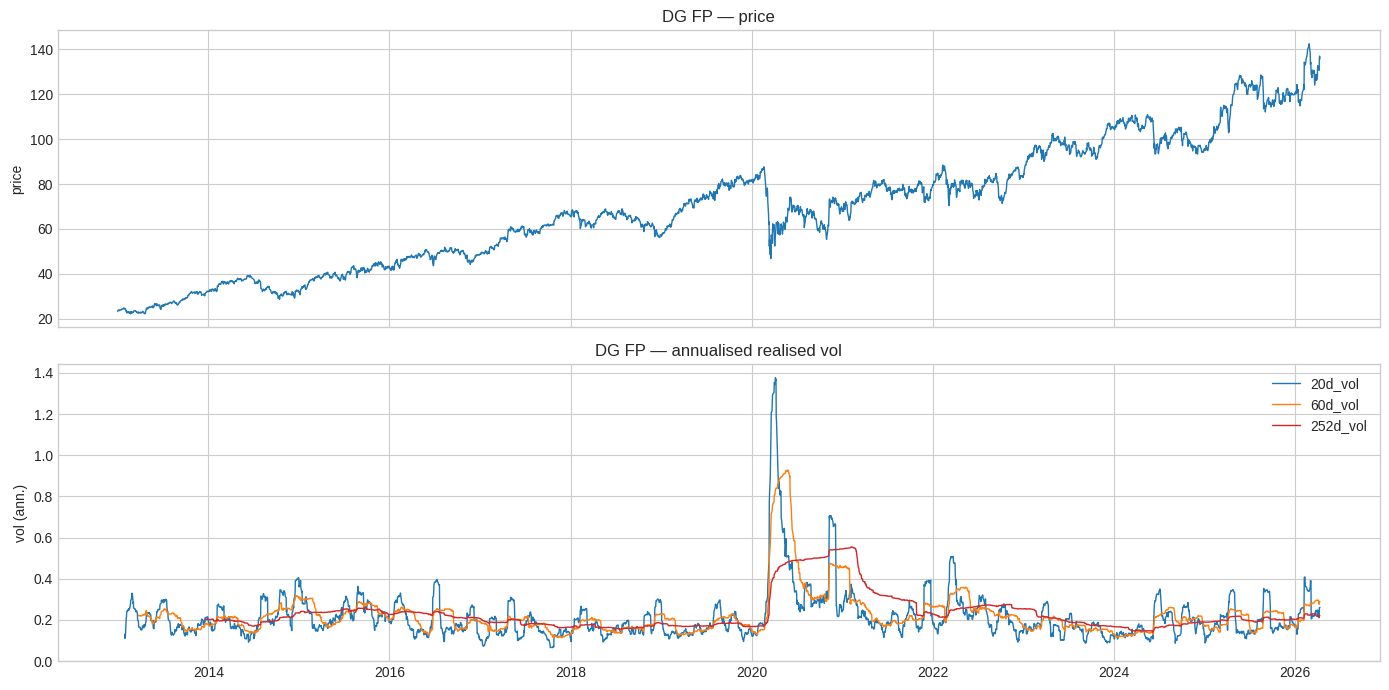

In [11]:
TICKER = "DG FP"

one = stocks.loc[stocks["ticker"] == TICKER].set_index("date").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(one.index, one["price"], linewidth=1)
axes[0].set_title(f"{TICKER} — price")
axes[0].set_ylabel("price")

for w, col in [("20d_vol", "tab:blue"), ("60d_vol", "tab:orange"), ("252d_vol", "tab:red")]:
    axes[1].plot(one.index, one[w], linewidth=1, label=w, color=col)
axes[1].set_title(f"{TICKER} — annualised realised vol")
axes[1].set_ylabel("vol (ann.)"); axes[1].legend()

plt.tight_layout(); plt.show()

## 5. CPD sanity — rolling severity ν on a single stock

Rolls `cpd_scores(returns, lbw)` from `src/cpd.py` over 1d log returns with a
lookback `LBW`, stride `STRIDE` (GP fits are slow, so we don't run every day).
High ν = strong regime shift detected inside the window.

In [12]:
from cpd import cpd_scores

LBW = 21
STRIDE = 5

series = one["1d_log_ret"].dropna()
dates = series.index.to_numpy()
rets = series.to_numpy()

end_idx = np.arange(LBW, len(rets), STRIDE)
nu_vals = np.empty(len(end_idx))
gamma_vals = np.empty(len(end_idx))
for i, j in enumerate(end_idx):
    nu_vals[i], gamma_vals[i] = cpd_scores(rets[j - LBW:j], lbw=LBW)

cpd_df = pd.DataFrame(
    {"nu": nu_vals, "gamma": gamma_vals},
    index=pd.to_datetime(dates[end_idx - 1]),
)
print(f"CPD: {len(cpd_df)} windows | ν mean={cpd_df['nu'].mean():.3f} | "
      f"top-5 dates:\n{cpd_df['nu'].nlargest(5)}")

CPD: 689 windows | ν mean=0.817 | top-5 dates:
2026-02-25    1.000000
2026-01-14    0.999999
2025-12-31    0.999993
2016-06-29    0.999992
2014-12-17    0.999992
Name: nu, dtype: float64


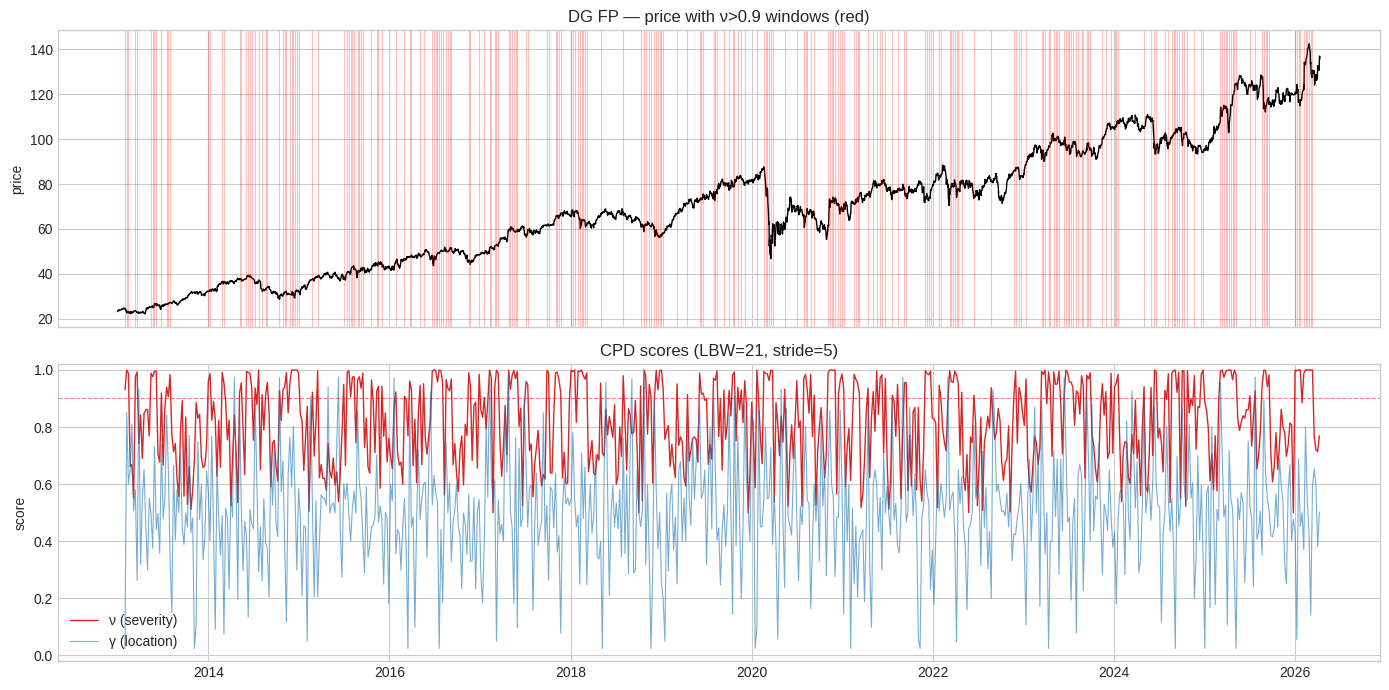

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(one.index, one["price"], linewidth=1, color="black")
hot = cpd_df.index[cpd_df["nu"] > 0.9]
for d in hot:
    axes[0].axvline(d, color="red", alpha=0.25, linewidth=0.8)
axes[0].set_title(f"{TICKER} — price with ν>0.9 windows (red)")
axes[0].set_ylabel("price")

axes[1].plot(cpd_df.index, cpd_df["nu"], linewidth=1, label="ν (severity)", color="tab:red")
axes[1].plot(cpd_df.index, cpd_df["gamma"], linewidth=0.8, label="γ (location)",
             color="tab:blue", alpha=0.6)
axes[1].axhline(0.9, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_title(f"CPD scores (LBW={LBW}, stride={STRIDE})")
axes[1].set_ylabel("score"); axes[1].set_ylim(-0.02, 1.02); axes[1].legend()

plt.tight_layout(); plt.show()